# Assignment 3

Authors: Julia Wlodarska (S5965780), Lara van den Broek (S5883288), Tessa van Staalduinen (S5999286)

This notebook implements ...

# Transformer fine-tuning


# Imports

In [ ]:
# Standard library
import random
import sys
sys.path.append("..")

# Third-party libraries
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import copy

# Local
from src import (
    basic_text_cleaning,  
    create_vocabulary,
    max_len_calculations,
    plot_sequence_length_distribution,
    text_to_sequence,
    AGNewsDataset
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Hyperparameters

In [ ]:
TRANSFORMER_CONFIG = {
    "model_name": "distilbert-base-uncased",  # lightweight; swap for bert-base-uncased / roberta-base
    "max_len": 128,          # DistilBERT handles up to 512; 128 covers 90 %+ of AG News
    "batch_size": 32,
    "lr": 2e-5,              # standard fine-tuning range for BERT-family
    "epochs": 4,
    "patience": 2,           # early stopping
    "warmup_ratio": 0.1,     # fraction of total steps used for LR warm-up
    "num_classes": 4,
    "weight_decay": 0.01,
}

## Load the data and split

In [4]:
# Dataset loading
# Classes: World (1), Sports (2), Business (3), Sci/Tech (4)
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
df_train = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["train"], lines=True)
test_dataset = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["test"], lines=True)

# Map integers to class names
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

# Train-dev splits (10% of training data as a development set)
train_dataset, dev_dataset = train_test_split(
    df_train,
    test_size=0.1,
    random_state=42,
    stratify=df_train["label"]
)

print(f"Training split: {len(train_dataset)} examples")
print(f"Development split: {len(dev_dataset)} examples")
print(f"Testing split: {len(test_dataset)} examples")

# Combine titles and descriptions
X_train = train_dataset["title"] + " " + train_dataset["description"]
y_train = train_dataset["label"]

X_dev = dev_dataset["title"] + " " + dev_dataset["description"]
y_dev = dev_dataset["label"]

X_test = test_dataset["title"] + " " + test_dataset["description"]
y_test = test_dataset["label"]

/home/wlodarskajulia/NLP_ass_2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training split: 108000 examples
Development split: 12000 examples
Testing split: 7600 examples


# Vocabulary

Vocabulary size: 73755
Average length: 37.8555
Max length: 171


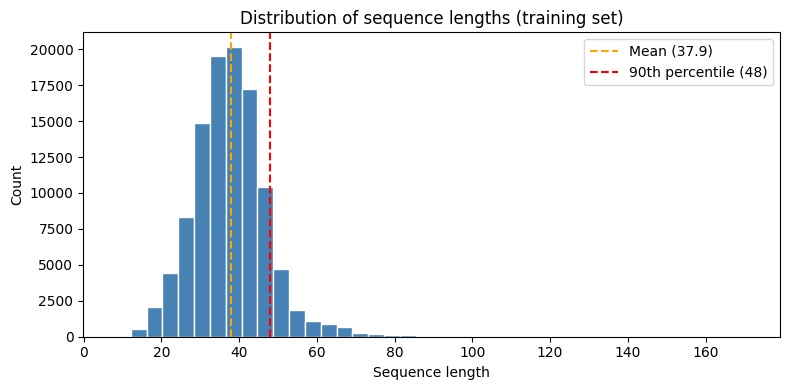

In [ ]:
# Build vocabulary
vocab = create_vocabulary(X_train.tolist(), min_freq=2)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Convert cleaned text to token sequences
X_train_seq = [text_to_sequence(basic_text_cleaning(text), vocab) for text in X_train]

# Decide max length
max_len = max_len_calculations(X_train_seq, percentile=90)
TRANSFORMER_CONFIG["max_len"] = max_len
plot_sequence_length_distribution(X_train_seq)

# Tokenizer and model

In [ ]:
# Hugging Face tokenizer for DistilBERT
# AutoTokenizer chooses the right tokenizer for a given model
tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_CONFIG["model_name"])
# without pretrained it would give random predictions, and this model has already learned language
# patterns from a hugest text dataset
 
model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_CONFIG["model_name"],
    num_labels=TRANSFORMER_CONFIG["num_classes"],
)

# fine-tuning: we’ll adjust it a little for our specific task (AG News) rather than training from scratch
model = model.to(device)

# Data loaders

In [ ]:
def to_zero_indexed(series):
    return (series - 1).tolist()

train_labels_0 = to_zero_indexed(y_train)
dev_labels_0   = to_zero_indexed(y_dev)
test_labels_0  = to_zero_indexed(y_test)

# DataLoader wraps the Dataset to create batches automatically
# each batch_size=32
# shuffle=True randomizes order so model doesn't memorize order 
train_loader = DataLoader(
    AGNewsDataset(X_train, train_labels_0, tokenizer, TRANSFORMER_CONFIG["max_len"]),
    batch_size=TRANSFORMER_CONFIG["batch_size"],
    shuffle=True,
)
dev_loader = DataLoader(
    AGNewsDataset(X_dev, dev_labels_0, tokenizer, TRANSFORMER_CONFIG["max_len"]),
    batch_size=TRANSFORMER_CONFIG["batch_size"],
    shuffle=False,
)
test_loader = DataLoader(
    AGNewsDataset(X_test, test_labels_0, tokenizer, TRANSFORMER_CONFIG["max_len"]),
    batch_size=TRANSFORMER_CONFIG["batch_size"],
    shuffle=False,
)

# Optimizer and scheduler

In [ ]:
# Optimizer tell PyTorch how to update model weights
# weight decay is a small penalty to reduce overfitting
optimizer = AdamW(
    model.parameters(),
    lr=TRANSFORMER_CONFIG["lr"],
    weight_decay=TRANSFORMER_CONFIG["weight_decay"],
)
 
total_steps = len(train_loader) * TRANSFORMER_CONFIG["epochs"]
warmup_steps = int(total_steps * TRANSFORMER_CONFIG["warmup_ratio"])

# Scheduler adjusts learning rate during training
# Helps transformers train more stably
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
 
criterion = torch.nn.CrossEntropyLoss()

# Training

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
 
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)
 
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
 
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
 
    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1

# Evaluation

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
 
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)
 
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            total_loss += loss.item()
 
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
 
    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1, all_preds, all_labels

# Training loop

In [ ]:
history = {"train_loss": [], "dev_loss": [], "train_acc": [], "dev_acc": [],
           "train_f1": [], "dev_f1": []}
 
best_dev_f1    = -1.0
best_model_wts = None
epochs_no_improve = 0
 
print(f"\nFine-tuning {TRANSFORMER_CONFIG['model_name']} on AG News …\n")
print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Train F1':>8}  "
      f"{'Dev Loss':>8}  {'Dev Acc':>7}  {'Dev F1':>6}")
print("-" * 72)
 
for epoch in range(1, TRANSFORMER_CONFIG["epochs"] + 1):
    tr_loss, tr_acc, tr_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )
    dv_loss, dv_acc, dv_f1, _, _ = evaluate(model, dev_loader, criterion, device)
 
    history["train_loss"].append(tr_loss)
    history["dev_loss"].append(dv_loss)
    history["train_acc"].append(tr_acc)
    history["dev_acc"].append(dv_acc)
    history["train_f1"].append(tr_f1)
    history["dev_f1"].append(dv_f1)
 
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {tr_f1:>8.4f}  "
          f"{dv_loss:>8.4f}  {dv_acc:>7.4f}  {dv_f1:>6.4f}")
 
    # Early stopping
    if dv_f1 > best_dev_f1:
        best_dev_f1    = dv_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= TRANSFORMER_CONFIG["patience"]:
            print(f"\nEarly stopping triggered after epoch {epoch}.")
            break
 
# Restore best weights before test evaluation
model.load_state_dict(best_model_wts)
print(f"\nBest dev Macro-F1: {best_dev_f1:.4f}")
 
 
# Final test evaluation
_, test_acc, test_f1, test_preds, test_labels_list = evaluate(
    model, test_loader, criterion, device
)
 
print(f"\n{'='*40}")
print(f"  Test Accuracy : {test_acc:.4f}")
print(f"  Test Macro-F1 : {test_f1:.4f}")
print(f"{'='*40}\n")
 
 
# Learning curves
def plot_learning_curves(history, title="Transformer Learning Curves"):
    epochs_ran = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
    axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss", marker="o")
    axes[0].plot(epochs_ran, history["dev_loss"],   label="Dev Loss",   marker="o")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy Loss")
    axes[0].legend()
 
    axes[1].plot(epochs_ran, history["train_f1"], label="Train Macro-F1", marker="o")
    axes[1].plot(epochs_ran, history["dev_f1"],   label="Dev Macro-F1",   marker="o")
    axes[1].set_title("Macro-F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro-F1")
    axes[1].legend()
 
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()
 
plot_learning_curves(history)
 
 
# Confusion matrix
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
 
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm
 
cm_transformer = plot_confusion_matrix(
    test_labels_list, test_preds, CLASS_NAMES, title="DistilBERT — Test Set"
)

# Error analysis

In [ ]:
def collect_errors(texts, true_labels, pred_labels, label_map, n=20):
    """Return a DataFrame of misclassified examples."""
    texts_list = texts.tolist() if hasattr(texts, "tolist") else list(texts)
    rows = []
    for i, (true, pred) in enumerate(zip(true_labels, pred_labels)):
        if true != pred:
            rows.append({
                "text":       texts_list[i],
                "true_label": label_map[true + 1],   # back to 1-indexed for readability
                "pred_label": label_map[pred + 1],
            })
    return pd.DataFrame(rows).head(n)
 
error_df = collect_errors(X_test, test_labels_list, test_preds, label_map, n=20)
print(f"\nFirst 20 misclassified examples (Transformer):\n")
pd.set_option("display.max_colwidth", 120)
print(error_df.to_string(index=False))